# 26. Angular models: `CovariantAngular` vs `ZemachP`/`ZemachPstar`

**Objectives:**
- Build the same spin-2 resonance with `Resonance(..., angular=...)` set to each of
  `CovariantAngular` (the default), `ZemachP`, and `ZemachPstar`.
- Evaluate the resulting angular factor along the physical Dalitz-plot boundary and
  plot the three shapes together.
- Confirm from their docstrings why `ZemachP` and `ZemachPstar` differ: `ZemachP` uses
  the bachelor momentum `p` in the *resonance* rest frame, while `ZemachPstar` uses the
  bachelor momentum `p*` in the *parent* rest frame.

Run cells top to bottom in a fresh kernel. Masses are in GeV, invariants in GeV²,
daughter indices start at zero. `GooFitLegacyAngular` is intentionally out of scope
here -- it only exists to reproduce one historical fit (see its docstring).

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    CovariantAngular, DecayChannel, DecayModel, PhaseSpaceSample, RealImag,
    Resonance, ZemachP, ZemachPstar, covariant_kinematics_from_invariants,
    dalitz_s13_limits,
)

## 1. Three models of the same spin-2 resonance

`angular=` is a plain keyword on `Resonance`; everything else about the component
(lineshape, mass, width, spin) stays fixed so only the angular factor changes. Spin 2
makes the three conventions' mass-dependence visibly different (spin 1 would still
differ, but by a smaller margin).

In [2]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
mpi = 0.13957
pole_mass, pole_width = 1.2755, 0.1867  # f2(1270)-like, illustrative only

def make_model(angular):
    return DecayModel(
        channel,
        [Resonance("f2", pair=(0, 1), coefficient=RealImag(1.0, 0.0),
                   mass=pole_mass, width=pole_width, spin=2, angular=angular)],
        normalization_method="square-dalitz", normalization_pair=(0, 1),
        normalization_resolution=40,
    )

models = {
    "CovariantAngular (default)": make_model(CovariantAngular()),
    "ZemachP": make_model(ZemachP()),
    "ZemachPstar": make_model(ZemachPstar()),
}

## 2. Scan the Dalitz-plot boundary

`cos_theta = +1` corresponds exactly to the lower physical edge of `s13` at fixed
`s12`, `dalitz_s13_limits`'s first return value. Scanning `s12` along that edge holds
the helicity angle fixed while the resonance invariant mass runs across its physical
range -- exactly the momentum-dependence the two Zemach frames disagree about.

In [3]:
masses = (mpi, mpi, mpi)
s12_low = (masses[0] + masses[1]) ** 2
s12_high = (channel.parent_mass - masses[2]) ** 2
s12_scan = jnp.linspace(s12_low + 1e-4, s12_high - 1e-4, 400)
s13_min, _ = dalitz_s13_limits(s12_scan, mother_mass=channel.parent_mass, masses=masses)
s23_scan = channel.parent_mass**2 + sum(m**2 for m in masses) - s12_scan - s13_min

sample = PhaseSpaceSample(s12=s12_scan, s13=s13_min, s23=s23_scan, weights=jnp.ones_like(s12_scan))
kin = covariant_kinematics_from_invariants(
    s12_scan, s13_min, parent_mass=channel.parent_mass,
    daughter_mass=masses[0], partner_mass=masses[1], bachelor_mass=masses[2],
)
print("cos_theta along this edge (should be ~1):", float(jnp.min(kin.cos_theta)), float(jnp.max(kin.cos_theta)))

cos_theta along this edge (should be ~1): 0.9999999999999959 1.0


## 3. Plot the resulting intensity shapes

Each model's `intensity` is `|A|^2` of the single resonance component evaluated on the
same `sample`, so any difference in the curves comes entirely from the angular factor.

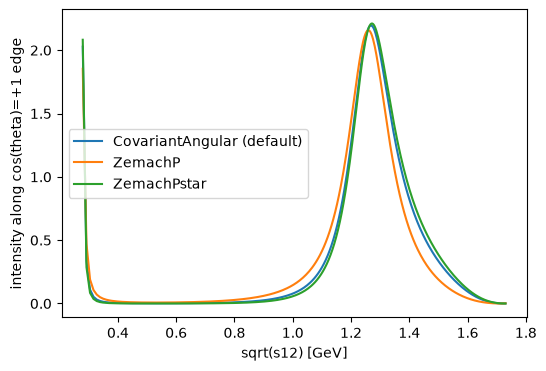

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, model in models.items():
    truth = {p.name: p.value for p in model.parameters}
    intensity = model.intensity(sample.as_dict(), truth)
    ax.plot(jnp.sqrt(s12_scan), intensity, label=label)
ax.set(xlabel="sqrt(s12) [GeV]", ylabel="intensity along cos(theta)=+1 edge")
ax.legend()
plt.show()

`ZemachP` uses `p` (bachelor momentum in the resonance rest frame) inside the shared
Zemach polynomial, `ZemachPstar` uses `p*` (bachelor momentum in the parent rest
frame) instead, and `CovariantAngular` additionally carries a `p**2 / parent_mass**2`
correction term (see `dynamics/angular.py`) absent from either Zemach convention. All
three reduce to the same angular *polynomial* in `cos_theta` at any fixed mass point --
the curves above differ only through their momentum-dependent prefactors, which is
exactly what evolves differently frame-to-frame across the resonance's mass range.

## Continue learning

See [dynamics structure](../../docs/dynamics_structure.md) for the full amplitude
convention. Return to [the course guide](TUTORIALS.md).